# REINFORCE and REINFORCE with Baseline

Policy gradient methods parametrise the policy directly as a tabular softmax
over (state, action) pairs and update parameters using gradient estimates from
full episodes.

| Algorithm | Return estimate | Variance |
|-----------|----------------|----------|
| **REINFORCE** | Monte-Carlo return G_t | High |
| **REINFORCE + baseline** | G_t - V(s_t) | Lower (baseline is unbiased) |

> **Note on `abs_err` metric:** for policy-gradient agents `V_est` is the
> value of the *current policy*, not V*. A random policy incurs ~1000 cost
> per wall collision, so `abs_err` is very large early in training. The
> canonical comparison metric is `policy_err`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from experiments.run_all import (
    load_config, run_algorithm, run_episode,
    _make_reinforce, _make_reinforce_baseline,
)
from environment.gridworld import GridWorldEnv
from utils.plotting import (
    plot_multi_curves, plot_learning_curves,
    plot_value_heatmap, plot_vstar_heatmap,
    plot_policy_arrows, plot_summary_bar, save_figure,
)
from utils.metrics import V_STAR, policy_eval_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## 0. Hyperparameters

In [2]:
cfg = load_config()

print(f"gamma          = {cfg['environment']['gamma']}")
print(f"n_episodes     = {cfg['environment']['n_episodes']}")
print()
print('REINFORCE')
print(f"  lr_policy    = {cfg['reinforce']['lr_policy']}")
print(f"  lr_baseline  = {cfg['reinforce']['lr_baseline']}  (REINFORCE+baseline only)")

gamma          = 0.85
n_episodes     = 1500

REINFORCE
  lr_policy    = 0.01
  lr_baseline  = 0.1  (REINFORCE+baseline only)


## 1. Algorithm Details

Both variants use a tabular softmax policy with parameters `theta` (shape 64x9).

```
pi(a|s) = softmax(theta[s, :])
```

After a full episode, for each time step t:

```
G_t = sum_{k=t}^{T} gamma^(k-t) * cost_k          # discounted return
delta_t = G_t - V[s_t]                             # baseline-corrected (REINFORCE+baseline only)

# Cost-minimisation gradient (theta update reduces pi(a_t|s_t) when G_t > 0):
theta[s_t, a_t] += lr * delta * (1 - pi(a_t|s_t))  -- actually: grad = pi - I_a
theta[s_t, a]   -= lr * delta * pi(a|s_t)  for a != a_t
```

The baseline `V(s_t)` is updated online:
```
V[s_t] += lr_baseline * (G_t - V[s_t])
```

## 2. Running the Experiments

In [3]:
nb_cfg = {**cfg, 'environment': {**cfg['environment'], 'n_runs': 3}}

In [4]:
print('Running REINFORCE ...')
rf_results = run_algorithm('reinforce', _make_reinforce, nb_cfg, verbose=True)

Running REINFORCE ...


22:34:57  INFO      reinforce               run 1/3  abs_err(final)=126.0143  23.0s
22:35:08  INFO      reinforce               run 2/3  abs_err(final)=48.8729  34.2s
22:35:24  INFO      reinforce               run 3/3  abs_err(final)=0.9824  50.1s


In [7]:
print('Running REINFORCE + baseline ...')
rfb_results = run_algorithm('reinforce_baseline', _make_reinforce_baseline, nb_cfg, verbose=True)

Running REINFORCE + baseline ...


22:37:18  INFO      reinforce_baseline      run 1/3  abs_err(final)=467.7586  19.9s
22:37:27  INFO      reinforce_baseline      run 2/3  abs_err(final)=288.8344  29.1s
22:37:32  INFO      reinforce_baseline      run 3/3  abs_err(final)=289.9148  34.5s


## 3. Learning Curves

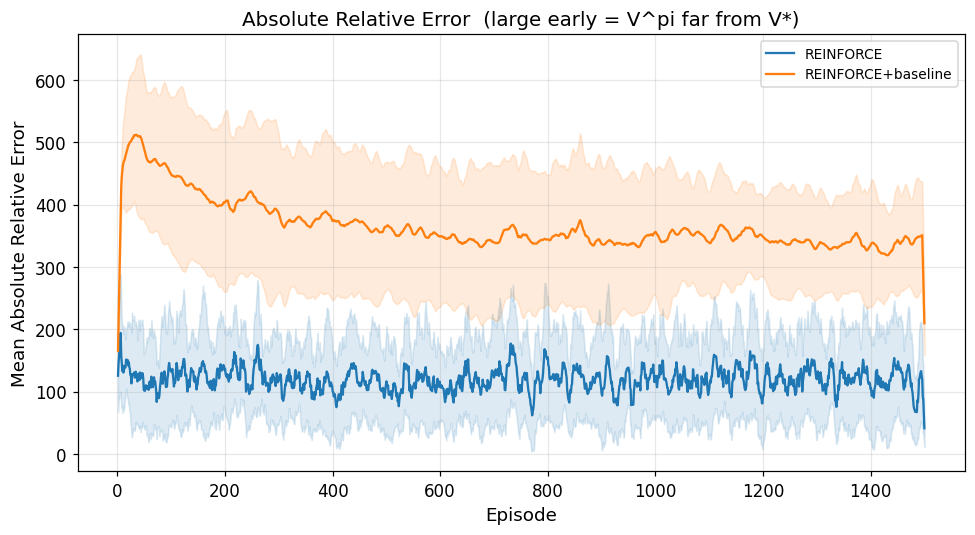

In [8]:
results_map = {
    'REINFORCE':          rf_results,
    'REINFORCE+baseline': rfb_results,
}

fig = plot_multi_curves(
    results_map, metric='abs_err',
    title='Absolute Relative Error  (large early = V^pi far from V*)',
    smooth=10,
)
save_figure(fig, '03_abs_err')
plt.show()

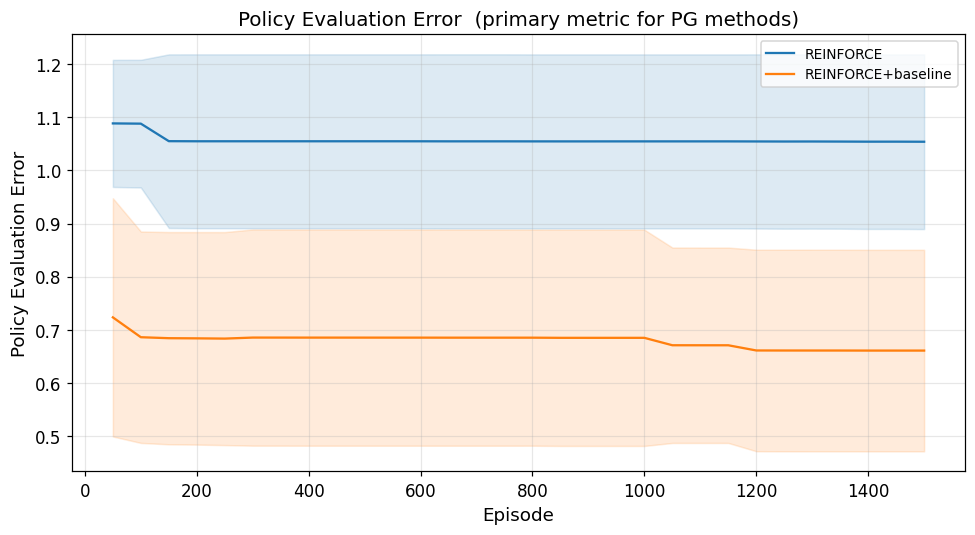

In [9]:
fig = plot_multi_curves(
    results_map, metric='policy_err',
    title='Policy Evaluation Error  (primary metric for PG methods)',
)
save_figure(fig, '03_policy_err')
plt.show()

## 4. Return Variance Analysis

The variance of the Monte-Carlo return is the main challenge for REINFORCE.
We can observe it indirectly through the spread of per-run policy errors.

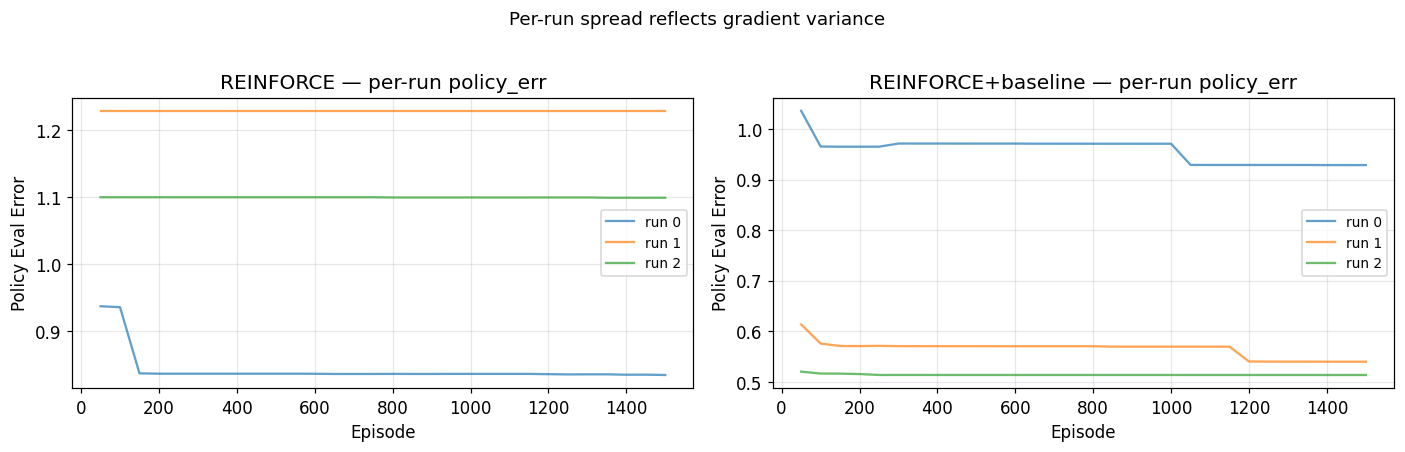

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ckpt = rf_results['checkpoint_eps'] + 1

for run in range(rf_results['policy_err'].shape[0]):
    axes[0].plot(ckpt, rf_results['policy_err'][run], alpha=0.7,
                 label=f'run {run}')
axes[0].set_title('REINFORCE — per-run policy_err')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Policy Eval Error')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

ckpt = rfb_results['checkpoint_eps'] + 1
for run in range(rfb_results['policy_err'].shape[0]):
    axes[1].plot(ckpt, rfb_results['policy_err'][run], alpha=0.7,
                 label=f'run {run}')
axes[1].set_title('REINFORCE+baseline — per-run policy_err')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Policy Eval Error')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Per-run spread reflects gradient variance', fontsize=12, y=1.02)
fig.tight_layout()
save_figure(fig, '03_variance_comparison')
plt.show()

## 5. Value Function and Policy

In [11]:
n_eps  = cfg['environment']['n_episodes']
max_st = cfg['environment']['max_steps_per_episode']

agents = {}
for name, factory in [('REINFORCE', _make_reinforce),
                       ('REINFORCE+baseline', _make_reinforce_baseline)]:
    agent = factory(np.random.default_rng(42), cfg)
    env   = GridWorldEnv(np.random.default_rng(43))
    for ep in range(n_eps):
        run_episode(agent, env, max_st, ep)
    agents[name] = agent
    print(f'{name:<22}  policy_err={policy_eval_error(agent.get_policy()):.4f}')

REINFORCE               policy_err=0.9550
REINFORCE+baseline      policy_err=0.6038


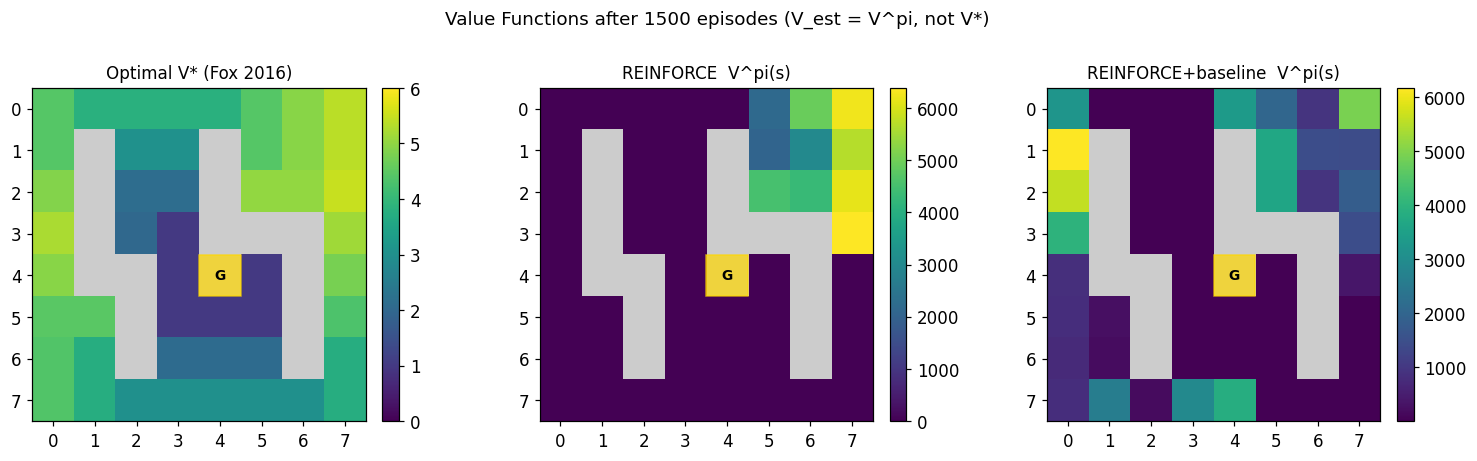

In [13]:
# For policy-gradient agents, V_est = V^pi (critic), not min Q.
# The scale here reflects the current-policy value, not V*.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_vstar_heatmap(ax=axes[0])
plot_value_heatmap(agents['REINFORCE'].get_value_estimate(),
                   title='REINFORCE  V^pi(s)', ax=axes[1])
plot_value_heatmap(agents['REINFORCE+baseline'].get_value_estimate(),
                   title='REINFORCE+baseline  V^pi(s)', ax=axes[2])
fig.suptitle('Value Functions after 1500 episodes (V_est = V^pi, not V*)',
             fontsize=12, y=1.02)
fig.tight_layout()
save_figure(fig, '03_value_heatmaps')
plt.show()

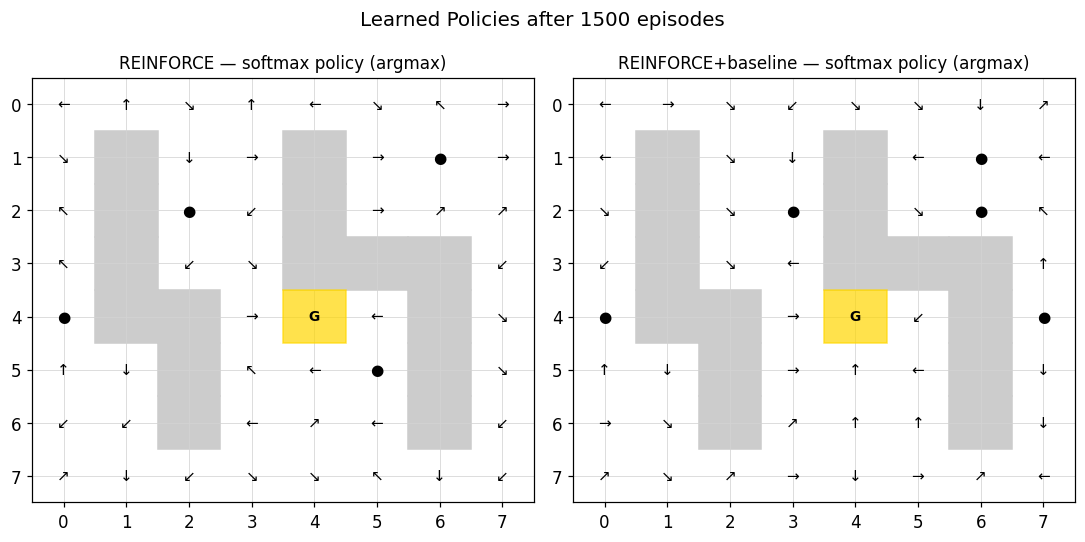

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_policy_arrows(agents['REINFORCE'].get_policy(),
                   title='REINFORCE — softmax policy (argmax)', ax=axes[0])
plot_policy_arrows(agents['REINFORCE+baseline'].get_policy(),
                   title='REINFORCE+baseline — softmax policy (argmax)', ax=axes[1])
fig.suptitle('Learned Policies after 1500 episodes', fontsize=13)
fig.tight_layout()
save_figure(fig, '03_policy_arrows')
plt.show()

## 6. Summary

REINFORCE               policy_err=1.0541+/-0.1645
REINFORCE+baseline      policy_err=0.6609+/-0.1897


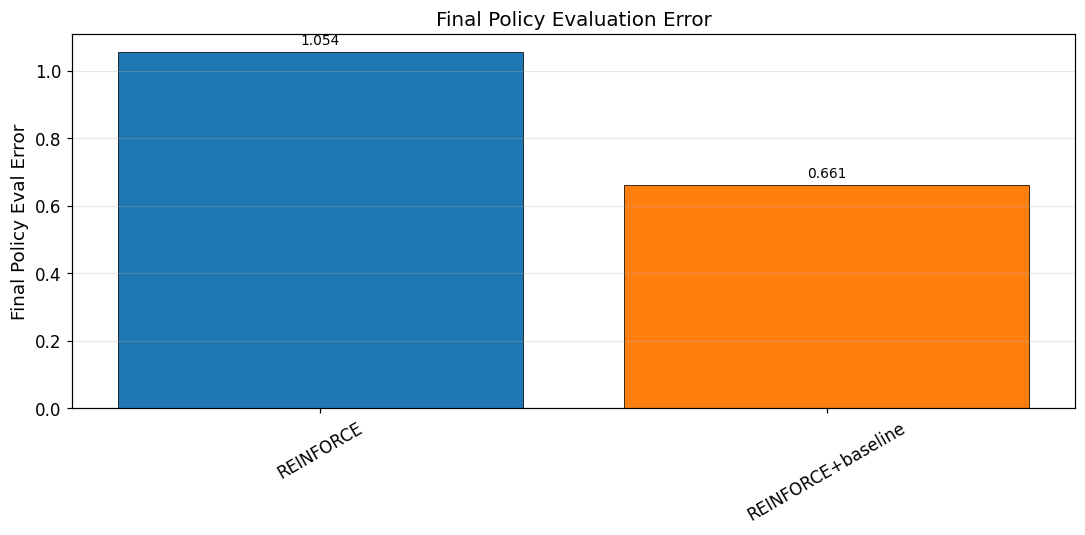

In [15]:
def final_stats(res, name):
    pe_m = res['policy_err'][:, -1].mean()
    pe_s = res['policy_err'][:, -1].std()
    print(f'{name:<22}  policy_err={pe_m:.4f}+/-{pe_s:.4f}')
    return pe_m

final_pol = {
    'REINFORCE':          final_stats(rf_results,  'REINFORCE'),
    'REINFORCE+baseline': final_stats(rfb_results, 'REINFORCE+baseline'),
}

fig = plot_summary_bar(final_pol, title='Final Policy Evaluation Error')
save_figure(fig, '03_final_bar')
plt.show()

## 7. Hyperparameter Tuning

Policy-gradient methods are sensitive to the learning rate — high variance in G_t
can destabilise training if α is too large. We sweep:
- `lr_policy` for REINFORCE
- `lr_policy` and `lr_baseline` independently for REINFORCE+baseline

In [16]:
from algorithms.reinforce import REINFORCEAgent, REINFORCEWithBaselineAgent
from utils.metrics import policy_eval_error

GAMMA  = cfg['environment']['gamma']
N_EPS  = cfg['environment']['n_episodes']
MAX_ST = cfg['environment']['max_steps_per_episode']
TUNE_RUNS = 3

def run_sweep_pg(factory, n_runs=TUNE_RUNS, n_eps=N_EPS, max_steps=MAX_ST, base_seed=0):
    errors = []
    for run in range(n_runs):
        rng_a = np.random.default_rng(base_seed + run * 1000)
        rng_e = np.random.default_rng(base_seed + run * 1000 + 1)
        agent = factory(rng_a)
        env   = GridWorldEnv(rng_e)
        for ep in range(n_eps):
            run_episode(agent, env, max_steps, ep)
        errors.append(policy_eval_error(agent.get_policy()))
    return float(np.mean(errors))

### 7a. REINFORCE: Policy Learning Rate

Swept over {0.001, 0.005, 0.01, 0.05, 0.1}.

  lr_policy=0.001  policy_err=0.5996
  lr_policy=0.005  policy_err=0.6719
  lr_policy=0.010  policy_err=1.0541
  lr_policy=0.050  policy_err=1.0126
  lr_policy=0.100  policy_err=1.0112

Best lr_policy (REINFORCE): 0.001  (policy_err=0.5996)


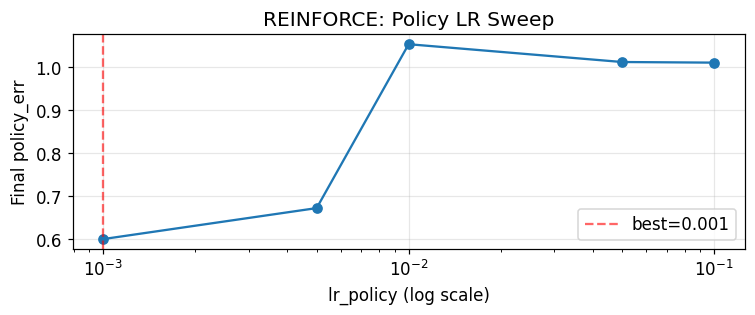

In [17]:
lr_vals = [0.001, 0.005, 0.01, 0.05, 0.1]

lr_rf_errors = {}
for lr in lr_vals:
    err = run_sweep_pg(lambda rng, lr=lr: REINFORCEAgent(rng, GAMMA, lr_policy=lr))
    lr_rf_errors[lr] = err
    print(f'  lr_policy={lr:.3f}  policy_err={err:.4f}')

best_lr_rf = min(lr_rf_errors, key=lr_rf_errors.get)
print(f'\nBest lr_policy (REINFORCE): {best_lr_rf}  '
      f'(policy_err={lr_rf_errors[best_lr_rf]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(lr_vals, [lr_rf_errors[l] for l in lr_vals], 'o-')
ax.axvline(best_lr_rf, color='red', linestyle='--', alpha=0.6, label=f'best={best_lr_rf}')
ax.set_xlabel('lr_policy (log scale)'); ax.set_ylabel('Final policy_err')
ax.set_title('REINFORCE: Policy LR Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '03_tune_rf_lr')
plt.show()

### 7b. REINFORCE+Baseline: Policy LR

Fixes `lr_baseline` at the config default (0.1) and sweeps `lr_policy`.

  lr_policy=0.001  policy_err=0.6165
  lr_policy=0.005  policy_err=0.6745
  lr_policy=0.010  policy_err=0.6609
  lr_policy=0.050  policy_err=0.9833
  lr_policy=0.100  policy_err=0.9502

Best lr_policy (REINFORCE+baseline): 0.001  (policy_err=0.6165)


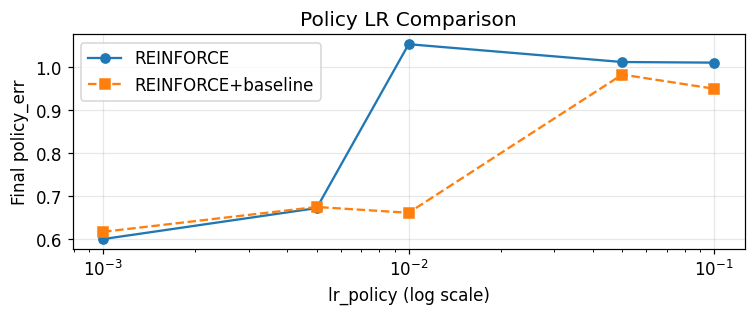

In [18]:
lr_baseline_fixed = cfg['reinforce']['lr_baseline']

lr_rfb_errors = {}
for lr in lr_vals:
    err = run_sweep_pg(lambda rng, lr=lr: REINFORCEWithBaselineAgent(
        rng, GAMMA, lr_policy=lr, lr_baseline=lr_baseline_fixed))
    lr_rfb_errors[lr] = err
    print(f'  lr_policy={lr:.3f}  policy_err={err:.4f}')

best_lr_rfb = min(lr_rfb_errors, key=lr_rfb_errors.get)
print(f'\nBest lr_policy (REINFORCE+baseline): {best_lr_rfb}  '
      f'(policy_err={lr_rfb_errors[best_lr_rfb]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(lr_vals, [lr_rf_errors[l]  for l in lr_vals], 'o-',  label='REINFORCE')
ax.semilogx(lr_vals, [lr_rfb_errors[l] for l in lr_vals], 's--', label='REINFORCE+baseline')
ax.set_xlabel('lr_policy (log scale)'); ax.set_ylabel('Final policy_err')
ax.set_title('Policy LR Comparison')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '03_tune_rfb_lr')
plt.show()

### 7c. REINFORCE+Baseline: Baseline LR

Fixes `lr_policy` at the best value found above; sweeps `lr_baseline` ∈ {0.01, 0.05, 0.1, 0.2, 0.5}.

  lr_baseline=0.010  policy_err=0.5149
  lr_baseline=0.050  policy_err=0.4744
  lr_baseline=0.100  policy_err=0.6165
  lr_baseline=0.200  policy_err=0.8277
  lr_baseline=0.500  policy_err=0.9109

Best lr_baseline (REINFORCE+baseline): 0.05  (policy_err=0.4744)


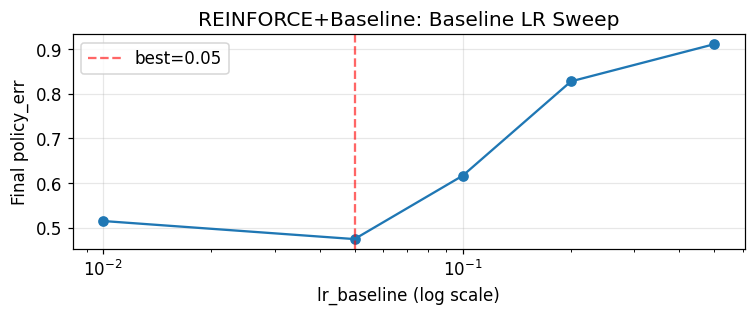

In [19]:
blr_vals = [0.01, 0.05, 0.1, 0.2, 0.5]

blr_errors = {}
for blr in blr_vals:
    err = run_sweep_pg(lambda rng, blr=blr: REINFORCEWithBaselineAgent(
        rng, GAMMA, lr_policy=best_lr_rfb, lr_baseline=blr))
    blr_errors[blr] = err
    print(f'  lr_baseline={blr:.3f}  policy_err={err:.4f}')

best_lr_baseline = min(blr_errors, key=blr_errors.get)
print(f'\nBest lr_baseline (REINFORCE+baseline): {best_lr_baseline}  '
      f'(policy_err={blr_errors[best_lr_baseline]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(blr_vals, [blr_errors[b] for b in blr_vals], 'o-')
ax.axvline(best_lr_baseline, color='red', linestyle='--', alpha=0.6, label=f'best={best_lr_baseline}')
ax.set_xlabel('lr_baseline (log scale)'); ax.set_ylabel('Final policy_err')
ax.set_title('REINFORCE+Baseline: Baseline LR Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '03_tune_rfb_blr')
plt.show()

In [20]:
print('=' * 50)
print('TUNED HYPERPARAMETERS — update default.yaml with these values')
print('=' * 50)
print(f'  reinforce.lr_policy   : {best_lr_rfb}  (used for both REINFORCE variants)')
print(f'  reinforce.lr_baseline : {best_lr_baseline}')

TUNED HYPERPARAMETERS — update default.yaml with these values
  reinforce.lr_policy   : 0.001  (used for both REINFORCE variants)
  reinforce.lr_baseline : 0.05


## Discussion

**REINFORCE** collects a full episode, computes discounted returns G_t for each
step, and uses them as an unbiased (but high-variance) estimate of the policy
gradient. The update pushes the policy away from actions that produce high cost.

**REINFORCE with baseline** subtracts a state-dependent baseline V(s_t) from
G_t. Because V(s_t) does not depend on the action taken at time t, this
subtraction does not bias the gradient estimate, but it significantly reduces
variance. The baseline is a running average of observed returns from state s.

**Cost-minimisation convention:** the gradient sign is reversed relative to the
standard reward-maximisation formula. When delta_t > 0 (return is above
baseline, i.e. current action was costly), we want to *decrease* pi(a_t|s_t),
so we update theta in the direction of (pi - I_a) rather than (I_a - pi).

**Key limitation** vs TD methods: REINFORCE only updates at the end of an
episode, so it receives no learning signal from incomplete trajectories. In
long episodes this slows convergence significantly compared to online TD.